In [1]:
import jax
import jax.numpy as jnp

# Sanity check: jax.grad of f(x) = x**2 + 3x should give 2x+3
# At x=2.0, expected: 2*2 + 3 = 7
f = lambda x: x**2 + 3*x
df = jax.grad(f)
print(df(2.0))

7.0


In [2]:
# Kill-check 2: single air/glass interface, normal incidence
# R = ((n1-n2)/(n1+n2))**2
n1 = 1.0  # air
n2 = 1.5  # glass

R = ((n1 - n2) / (n1 + n2))**2
T = 1 - R  # no absorption in glass/air
A = 0.0

print(f"R = {R:.4f}")
print(f"T = {T:.4f}")
print(f"A = {A:.4f}")
print(f"R + T + A = {R + T + A:.4f}")

R = 0.0400
T = 0.9600
A = 0.0000
R + T + A = 1.0000


In [3]:
import jax.numpy as jnp

def fresnel_interface(n1, n2):
    """2x2 interface matrix between materials n1 and n2"""
    return jnp.array([[1,    1   ],
                      [n1,  -n2  ]], dtype=complex)

def propagation_matrix(n, d, lam):
    """2x2 propagation matrix through layer of index n, thickness d, wavelength lam"""
    delta = 2 * jnp.pi * n * d / lam
    return jnp.array([[jnp.exp(1j * delta),  0                  ],
                      [0,                     jnp.exp(-1j * delta)]], dtype=complex)

# Test: at d=0, propagation matrix should be identity
P_test = propagation_matrix(1.5, 0.0, 500.0)
print("P at d=0:")
print(P_test)

P at d=0:
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


In [4]:
def tmm_single_layer(n0, n1, n2, d, lam):
    """
    TMM for a single layer stack: n0 / layer(n1, d) / n2
    n0: incident medium (air = 1.0)
    n1: layer refractive index  
    n2: substrate (glass = 1.5)
    d: layer thickness in nm
    lam: wavelength in nm
    Returns R
    """
    # Phase thickness of layer
    delta = 2 * jnp.pi * n1 * d / lam
    
    # Fresnel coefficients at each interface
    r01 = (n0 - n1) / (n0 + n1)  # air -> layer
    r12 = (n1 - n2) / (n1 + n2)  # layer -> glass
    
    # Total reflection coefficient (Fabry-Perot formula)
    r = (r01 + r12 * jnp.exp(2j * delta)) / (1 + r01 * r12 * jnp.exp(2j * delta))
    
    R = jnp.abs(r)**2
    return R

# Kill-check 3: d=0 should give same R as bare Fresnel (0.04)
R_tmm = tmm_single_layer(1.0, 1.5, 1.5, 0.0, 500.0)
print(f"TMM R at d=0: {R_tmm:.4f}")
print(f"Match with Fresnel: {jnp.abs(R_tmm - 0.04) < 1e-4}")

TMM R at d=0: 0.0400
Match with Fresnel: True


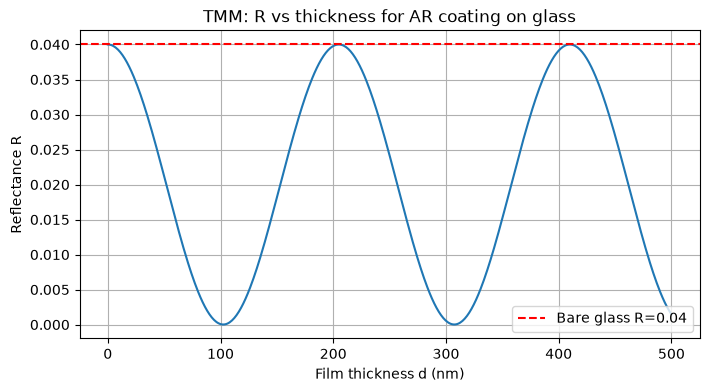

Minimum R: 0.000016 at d=307.6 nm
Maximum R: 0.040000


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Sweep thickness d from 0 to 500nm
d_values = jnp.linspace(0, 500, 500)
lam = 500.0  # 500nm wavelength (green light)
n0 = 1.0     # air
n1 = 1.22    # ideal AR coating index = sqrt(1.0 * 1.5)
n2 = 1.5     # glass

R_values = [float(tmm_single_layer(n0, n1, n2, d, lam)) for d in d_values]

plt.figure(figsize=(8,4))
plt.plot(d_values, R_values)
plt.axhline(0.04, color='r', linestyle='--', label='Bare glass R=0.04')
plt.xlabel('Film thickness d (nm)')
plt.ylabel('Reflectance R')
plt.title('TMM: R vs thickness for AR coating on glass')
plt.legend()
plt.grid(True)
plt.show()

print(f"Minimum R: {min(R_values):.6f} at d={d_values[jnp.argmin(jnp.array(R_values))]:.1f} nm")
print(f"Maximum R: {max(R_values):.6f}")

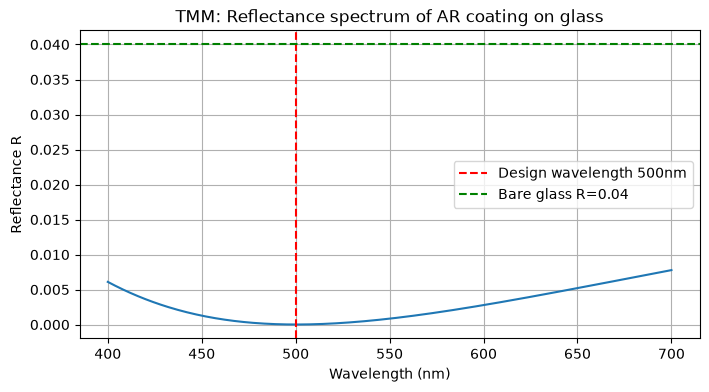

R at 500nm: 0.000015
R at 400nm: 0.006101
R at 700nm: 0.007781


In [6]:
# Wavelength sweep: fix d=102.5nm (quarter-wave at 500nm for n=1.22)
wavelengths = jnp.linspace(400, 700, 300)
d_fixed = 102.5
n0, n1, n2 = 1.0, 1.22, 1.5

# Vectorized version - faster than list comprehension
def R_at_wavelength(lam):
    return tmm_single_layer(n0, n1, n2, d_fixed, lam)

R_spectrum = jnp.vectorize(R_at_wavelength)(wavelengths)

plt.figure(figsize=(8,4))
plt.plot(wavelengths, R_spectrum)
plt.axvline(500, color='r', linestyle='--', label='Design wavelength 500nm')
plt.axhline(0.04, color='g', linestyle='--', label='Bare glass R=0.04')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance R')
plt.title('TMM: Reflectance spectrum of AR coating on glass')
plt.legend()
plt.grid(True)
plt.show()

print(f"R at 500nm: {float(R_at_wavelength(500.0)):.6f}")
print(f"R at 400nm: {float(R_at_wavelength(400.0)):.6f}")
print(f"R at 700nm: {float(R_at_wavelength(700.0)):.6f}")

In [7]:
# Step 1: synthetic target
d_true = 150.0
R_target = jnp.array([tmm_single_layer(1.0, 1.22, 1.5, d_true, lam) for lam in wavelengths])

print(f"R_target shape: {R_target.shape}")
print(f"R_target at 500nm: {float(R_target[50]):.6f}")

R_target shape: (300,)
R_target at 500nm: 0.028064


In [8]:
# Step 2b: vectorized loss function
def R_spectrum_at_d(d):
    return jnp.vectorize(lambda lam: tmm_single_layer(1.0, 1.22, 1.5, d, lam))(wavelengths)

def loss(d):
    R_model = R_spectrum_at_d(d)
    return jnp.sum((R_model - R_target)**2)

print(f"L(150): {loss(150.0):.6f}")
print(f"L(200): {loss(200.0):.6f}")

L(150): 0.000000
L(200): 0.110969


In [9]:
# Step 3: gradient
grad_loss = jax.grad(loss)
print(f"dL/dd at d=200: {float(grad_loss(200.0)):.6f}")

dL/dd at d=200: 0.003350


In [10]:
# Step 4: gradient descent
d = 200.0
lr = 1000.0
grad_loss = jax.grad(loss)

for i in range(50):
    g = grad_loss(d)
    d = d - lr * g
    if i % 10 == 0:
        print(f"step {i}: d={float(d):.2f}, L={float(loss(d)):.6f}")

print(f"\nFinal d: {float(d):.2f} (true: 150.0)")

step 0: d=196.65, L=0.099811
step 10: d=168.21, L=0.019337
step 20: d=155.21, L=0.001676
step 30: d=151.39, L=0.000121
step 40: d=150.37, L=0.000009

Final d: 150.11 (true: 150.0)


In [11]:
# Session 6: identifiability experiment
starting_guesses = [50.0, 100.0, 200.0, 300.0, 400.0]

for d_init in starting_guesses:
    d = float(d_init)
    for i in range(100):
        g = float(grad_loss(d))
        d = d - 1000.0 * g
    print(f"start={d_init:.0f} → final d={d:.2f}, L={float(loss(d)):.8f}")

start=50 → final d=67.00, L=0.08902057
start=100 → final d=150.00, L=0.00000000
start=200 → final d=150.00, L=0.00000000
start=300 → final d=365.23, L=0.01844797
start=400 → final d=365.34, L=0.01844785


You must install the tqdm library to use progress indicators with emcee



number of samples: 80000
d: mean = 258.22  std = 108.11


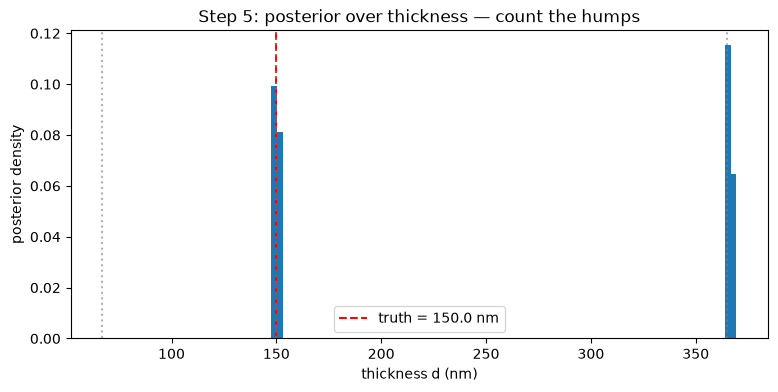

In [13]:
import numpy as np
import emcee

# ============================================================
# STEP 5: Port the validated machinery to TMM
# Recover thickness d from a NOISY reflectance spectrum.
# Question: is d identifiable, or does the posterior show
# multiple humps (the 67/150/365 ambiguity)?
# ============================================================

# --- 1. NOISY DATA: add gentle Gaussian noise to the clean target ---
noise_sigma = 0.005
R_target_np = np.array(R_target)                       # JAX array -> plain numpy
rng = np.random.default_rng(0)
R_noisy = R_target_np + rng.normal(0, noise_sigma, size=len(R_target_np))

# --- 2. log_prob: data passed as ARGUMENTS (the Step-4 lesson) ---
def log_prob_tmm(params, R_data):
    d = params[0]
    if d < 0 or d > 500:                               # prior: thickness in [0, 500] nm
        return -np.inf
    R_model = np.array(R_spectrum_at_d(d))             # run TMM forward model at this d
    resid = R_model - R_data
    return -0.5 * np.sum(resid**2) / noise_sigma**2

# --- 3. emcee: same scaffold as Step 4, now 1 parameter (d) ---
ndim = 1
nwalkers = 32
nsteps = 3000

# spread walkers across the WHOLE prior range, so they can find any valley
start = rng.uniform(20, 450, size=(nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob_tmm, args=(R_noisy,))
sampler.run_mcmc(start, nsteps, progress=True)

samples = sampler.get_chain(discard=500, flat=True)[:, 0]
print("\nnumber of samples:", len(samples))
print("d: mean =", round(samples.mean(), 2), " std =", round(samples.std(), 2))

# --- 4. LOOK at the posterior: one hump or several? ---
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))
plt.hist(samples, bins=80, density=True)
plt.axvline(d_true, color='r', linestyle='--', label=f'truth = {d_true} nm')
for guess in [67, 150, 365]:
    plt.axvline(guess, color='gray', linestyle=':', alpha=0.6)
plt.xlabel('thickness d (nm)')
plt.ylabel('posterior density')
plt.title('Step 5: posterior over thickness — count the humps')
plt.legend()
plt.show()

In [15]:
!pip install tqdm